In [1]:
# Intertemporal Choice: Do LLMs Discount the Future Like Humans?
### CPSY 1950 — Deep Learning in Brains, Minds & Machines
**Experiment:** Ruggeri et al. (2022) — Globalizability of intertemporal choice  
**Dataset:** Psych-101 (Binz et al., 2024) — `ruggeri2022globalizability/exp1.csv`  
**Models tested:** Llama-3.3-70B-Instruct, Mistral-Large-3 (+ frontier models after Apr 5)

---

## Project Overview

This notebook runs a behavioral experiment on large language models, treating them 
as cognitive subjects — the same way psychologists run experiments on human participants.

**The core question:** When humans choose between a smaller reward now and a larger 
reward later, they show systematic, irrational impatience. Do LLMs reproduce the same 
behavioral signature — or do they discount differently?

**Why it matters:** LLMs have read millions of words *describing* human decision-making 
biases, but have never actually waited for anything. This experiment tests whether 
formally knowing about a cognitive bias (Mahowald et al., 2024) is the same as 
functionally exhibiting it.

SyntaxError: invalid character '—' (U+2014) (508443451.py, line 3)

In [14]:
## Cell 2 — API Setup

We connect to Brown's LiteLLM endpoint, which proxies access to all course models 
(Llama, Mistral, and frontier models after TA review).

The API key is loaded from a `.env` file in this directory — never hardcoded — 
following standard security practice.

**Models available at this stage:**
- `Llama-3.3-70B-Instruct` — open-weight, different architecture from GPT-family
- `Mistral-Large-3` — second open-weight model for model-to-model comparison
- Frontier models (Claude, GPT) unlocked after draft poster submission Apr 5

SyntaxError: unterminated string literal (detected at line 3) (357774693.py, line 3)

In [15]:
from dotenv import load_dotenv
import os
from openai import OpenAI

load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

print("Connected. API key loaded:", os.getenv("OPENAI_API_KEY") is not None)

Connected. API key loaded: True


In [ ]:
## Cell 3 — Load Dataset and Filter to Experiment

We load **Psych-101** (Binz et al., 2024), a dataset of natural language transcripts 
from 160 psychological experiments across 60,092 human participants. It was created 
to train Centaur, a foundation model of human cognition.

**Our experiment:** `ruggeri2022globalizability/exp1.csv`  
Source: Ruggeri et al. (2022), *Nature Human Behaviour* — a large-scale cross-cultural 
study of intertemporal choice across 61 countries and 13,629 participants.

**Why this dataset?** The prompts are already formatted as natural language — the same 
format we send to LLMs — and the human response data is built in, giving us a direct 
comparison baseline. Each row is one participant's complete session.

**Experiment structure:** Participants chose between a smaller-sooner (SS) and 
larger-later (LL) reward across 10 trials, varying:
- Gains vs. losses (sign effect)
- Small vs. large amounts (magnitude effect)  
- 1-year vs. 2-year delays (delay sensitivity)
- Surface framing variations ("wait", "receive", "paying")

In [16]:
from datasets import load_dataset

# This downloads Psych-101 — takes about 1 minute the first time
dataset = load_dataset("marcelbinz/Psych-101", split="train")

# Filter to just the Ruggeri intertemporal choice experiment
EXPERIMENT = "ruggeri2022globalizability/exp1.csv"
itc_data = dataset.filter(lambda row: row["experiment"] == EXPERIMENT)

print(f"Experiment: {EXPERIMENT}")
print(f"Number of participants: {len(itc_data)}")

Experiment: ruggeri2022globalizability/exp1.csv
Number of participants: 11937


In [ ]:
## Cell 4 — Inspect a Real Prompt

Before writing any analysis code, we read one participant's actual session. 

**Key things to notice in the output:**
1. The option letters (G/C, H/X, etc.) are **randomized per participant** — this 
   prevents position bias and is a design choice we inherit from the original study
2. Each trial ends with `<<LETTER>>` — this is the human's actual choice, which 
   we will compare against the model's choice
3. The 10 trials vary systematically across the experimental conditions listed above

**Connection to course:** This is the raw behavioral data that Centaur was trained on. 
By running the same prompts through non-fine-tuned LLMs, we are asking whether 
behavioral alignment emerges from general language training alone — or whether it 
requires explicit fine-tuning on human behavioral data (as Centaur does).

In [17]:
# Print the first participant's full prompt
print(itc_data[0]["text"])

In the following you will be presented with multiple choices between two options G and C.
Please name which option you would prefer by pressing the corresponding key.

You have the choice between receiving 500$ immediately (press G) or receiving 550$ in one year (press C). You press <<G>>.
You have the choice between receiving 500$ immediately (press G) or receiving 600$ in one year (press C). You press <<C>>.
You have the choice between paying 500$ immediately (press G) or paying 550$ in one year (press C). You press <<G>>.
You have the choice between paying 500$ immediately (press G) or paying 510$ in one year (press C). You press <<C>>.
You have the choice between receiving 5000$ immediately (press G) or receiving 5500$ in one year (press C). You press <<G>>.
You have the choice between receiving 5000$ immediately (press G) or receiving 6000$ in one year (press C). You press <<C>>.
You have the choice between receiving 500$ in one year (press G) or receiving 600$ in two years (press

In [ ]:
## Cell 6 — Extract Individual Trials

Each dataset row is one participant's *entire session* (~10 decisions concatenated). 
We need to split it into individual decisions to score them one at a time.

**How it works:** The `extract_trials()` function uses a regular expression to find 
every `<<LETTER>>` token and splits the session at each one. For each split, it records:
- The **prompt** — everything the participant saw up to that point (the model gets this)
- The **human choice** — the letter inside `<< >>` (our ground truth to compare against)

**Important:** We use `r'(.*?)(<<[A-Z]>>)'` with `re.DOTALL` so the pattern matches 
across line breaks. The `.*?` is non-greedy — it captures the shortest possible match, 
ensuring we don't accidentally merge two trials into one.

**Running context:** Each trial's prompt *includes all previous trials and choices*. 
This means by trial 5, the model sees the full history of trials 1–4. This is by 
design — it mirrors what the human participant experienced and allows us to measure 
sequential dependencies (a key concern from the course's autoregressive artifacts 
confound discussion).

In [18]:
import re

def extract_trials(text):
    """
    Splits one participant's session into individual trials.
    Works regardless of which letters are used (H/X, G/C, etc.)
    Returns list of (prompt, human_choice) tuples.
    """
    trials = []
    pattern = r'(.*?)(<<[A-Z]>>)'  # matches ANY single capital letter
    matches = re.findall(pattern, text, re.DOTALL)
    
    running_context = ""
    for context_piece, choice in matches:
        running_context += context_piece
        prompt = running_context.strip()
        human_answer = choice.replace("<<", "").replace(">>", "")
        trials.append((prompt, human_answer))
        running_context += choice
    
    return trials

# Test on participant 0
trials = extract_trials(itc_data[0]["text"])

print(f"Total decisions for participant 0: {len(trials)}")
print()
print("--- TRIAL 1 ---")
print(trials[0][0][-250:])
print(f"\nHuman chose: {trials[0][1]}")
print()
print("--- TRIAL 3 (loss trial) ---")
print(trials[2][0][-250:])
print(f"\nHuman chose: {trials[2][1]}")

Total decisions for participant 0: 10

--- TRIAL 1 ---
ented with multiple choices between two options G and C.
Please name which option you would prefer by pressing the corresponding key.

You have the choice between receiving 500$ immediately (press G) or receiving 550$ in one year (press C). You press

Human chose: G

--- TRIAL 3 (loss trial) ---
 You press <<G>>.
You have the choice between receiving 500$ immediately (press G) or receiving 600$ in one year (press C). You press <<C>>.
You have the choice between paying 500$ immediately (press G) or paying 550$ in one year (press C). You press

Human chose: G


In [ ]:
## Cell 5 — Query the Model

This is the core experimental procedure. For each trial, we:
1. Take the prompt (everything up to the choice point)
2. Append `"\nYou press <<"` — signaling the model should complete the response
3. Send it to the LLM API and record which letter it returns

**Design decisions and their justification:**

`temperature=0.0` — deterministic responses. The same prompt always produces 
the same answer. This is important for reproducibility and means we are measuring 
the model's *modal* preference, not sampling from its distribution.

`max_tokens=3` — forces a short response. Without this constraint, models sometimes 
reason out loud ("It seems like I should...") rather than pressing a key. This was 
observed on loss trials in initial testing — the model hesitated on the paying condition, 
which is itself an interesting finding (noted in Slide 4: the model required explicit 
constraint on loss trials that humans do not need in a button-press lab setting).

`system message` — instructs the model to respond with only a single letter. This is 
our **confound mitigation** for the autoregressive artifacts confound: we ensure the 
format of the response is comparable across all models and conditions.

`get_valid_options()` — extracts the actual option letters from the prompt by searching 
for `(press LETTER)` patterns. This makes the parser robust to letter randomization 
across participants.

**Connection to Firestone (2020):** We are creating a "species-fair" comparison by 
giving the model the same information a human participant received — no more, no less.

In [19]:
import math

def get_valid_options(prompt):
    options = re.findall(r'\(press ([A-Z])\)', prompt)
    return list(set(options))

def ask_model_with_logprobs(prompt, model_name):
    valid_options = get_valid_options(prompt)
    options_str = " or ".join(valid_options)
    
    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {
                "role": "system",
                "content": f"You are participating in a psychology experiment. "
                           f"You must respond with ONLY a single letter ({options_str}). "
                           f"No explanation. No punctuation. Just the letter."
            },
            {
                "role": "user",
                "content": prompt + "\nYou press <<"
            }
        ],
        max_tokens=3,
        temperature=0.0,
        logprobs=True,
        top_logprobs=5
    )
    
    raw = response.choices[0].message.content.strip()
    
    chosen = None
    for char in raw:
        if char in valid_options:
            chosen = char
            break
    
    logprob_dict = {}
    if response.choices[0].logprobs:
        for token_logprob in response.choices[0].logprobs.content:
            main_token = token_logprob.token.strip()
            if main_token in valid_options:
                logprob_dict[main_token] = token_logprob.logprob
            for top in token_logprob.top_logprobs:
                cleaned = top.token.strip()
                if cleaned in valid_options and cleaned not in logprob_dict:
                    logprob_dict[cleaned] = top.logprob

    if len(logprob_dict) == 1 and len(valid_options) == 2:
        missing = [o for o in valid_options if o not in logprob_dict][0]
        logprob_dict[missing] = -10.0

    return chosen, logprob_dict

chosen_1, logprobs_1 = ask_model_with_logprobs(trials[0][0], "Llama-3.3-70B-Instruct")
print(f"Trial 1 - Gain ($500 now vs $550 in 1 year)")
print(f"Human: {trials[0][1]}  |  Model: {chosen_1}")
for option, lp in logprobs_1.items():
    print(f"  Option {option}: {math.exp(lp)*100:.1f}% confidence")

print()

chosen_3, logprobs_3 = ask_model_with_logprobs(trials[2][0], "Llama-3.3-70B-Instruct")
print(f"Trial 3 - Loss ($500 now vs $550 in 1 year)")
print(f"Human: {trials[2][1]}  |  Model: {chosen_3}")
for option, lp in logprobs_3.items():
    print(f"  Option {option}: {math.exp(lp)*100:.1f}% confidence")


Trial 1 - Gain ($500 now vs $550 in 1 year)
Human: G  |  Model: G
  Option G: 100.0% confidence
  Option C: 0.0% confidence

Trial 3 - Loss ($500 now vs $550 in 1 year)
Human: G  |  Model: G
  Option G: 100.0% confidence
  Option C: 0.0% confidence


In [ ]:
## Cell 6 — Run Full Experiment

We now run the complete pipeline across multiple participants and collect all results 
into a DataFrame for analysis.

**Scale for today (Studio I):** 5 participants × 10 trials = 50 API calls  
This takes ~2 minutes and is enough to confirm the pipeline works end-to-end.

**Scale for final analysis:** We will increase to 50+ participants per model before 
the draft poster deadline (Saturday Apr 5). With 11,937 participants in the dataset, 
we have far more data than we need.

**Models to run (in order):**
1. `Llama-3.3-70B-Instruct` — today
2. `Mistral-Large-3` — Thursday Studio II (model-to-model comparison)
3. Frontier models — after TA grants access Saturday

**What the DataFrame contains:** One row per trial, with columns for participant ID, 
trial number, model name, human choice, and model choice. This structure makes it 
easy to compute statistics and plot results across conditions.

**Addressing the aggregate fit ≠ process fidelity confound:** We collect trial-level 
data (not just overall averages) so we can examine whether the model's *pattern* of 
choices across trial types matches humans — not just the overall patience rate. A model 
could match the aggregate statistic while showing completely different behavior on gain 
vs. loss trials, or on small vs. large amount trials.

In [7]:
from tqdm import tqdm
import pandas as pd

def compute_nll(human_choice, logprob_dict):
    if human_choice in logprob_dict:
        return -logprob_dict[human_choice]
    return None

def run_experiment_with_nll(data, model_name, n_participants=5):
    results = []
    
    for i in tqdm(range(n_participants), desc=f"Running {model_name}"):
        participant_trials = extract_trials(data[i]["text"])
        
        for trial_idx, (prompt, human_choice) in enumerate(participant_trials):
            chosen, logprob_dict = ask_model_with_logprobs(prompt, model_name)
            nll = compute_nll(human_choice, logprob_dict)
            
            results.append({
                "participant": i,
                "trial": trial_idx,
                "model_name": model_name,
                "human_choice": human_choice,
                "model_choice": chosen,
                "prompt": prompt,
                "nll": nll,
            })
    
    return pd.DataFrame(results)

# Run on 5 participants to confirm everything works
df = run_experiment_with_nll(itc_data, "Llama-3.3-70B-Instruct", n_participants=5)

print(df[["participant", "trial", "human_choice", "model_choice", "nll"]].to_string())
print(f"\nTotal trials: {len(df)}")
print(f"Missing model responses: {df['model_choice'].isna().sum()}")
print(f"Missing NLL values: {df['nll'].isna().sum()}")

Running Llama-3.3-70B-Instruct: 100%|█████████████| 5/5 [00:35<00:00,  7.02s/it]

    participant  trial human_choice model_choice           nll
0             0      0            G            G  3.576278e-07
1             0      1            C            G  8.875140e+00
2             0      2            G            G  4.649151e-06
3             0      3            C            G  1.156251e+01
4             0      4            G            G  1.740304e-04
5             0      5            C            C  5.960463e-07
6             0      6            C            C  1.070967e-02
7             0      7            C            C  1.139643e-02
8             0      8            C            G  5.784330e+00
9             0      9            C            G  2.870821e+00
10            1      0            W            C  1.025004e+01
11            1      1            C            C  4.768370e-07
12            1      2            C            W  1.018754e+01
13            1      3            C            W  9.167618e-01
14            1      4            C            C  3.576

In [ ]:
## Cell 7 — Analysis and Visualization

**The key metric: patience rate**  
For each trial, we identify which option is "immediate" by searching for the word 
"immediately" in the prompt. Choosing the *other* option = patient choice. 
Patience rate = % of trials where the patient option was chosen.

**Three comparisons we compute:**

1. **Overall patience rate** — humans vs. each model  
   → Tests whether the model's aggregate behavior matches humans

2. **Sign effect** — patience rate on gain trials vs. loss trials  
   → Humans are less patient about losses (want to get pain over with)  
   → A rational agent shows no difference between gains and losses

3. **Magnitude effect** — patience rate on $500 trials vs. $5000 trials  
   → Humans discount smaller amounts more steeply  
   → Tests whether model sensitivity to amount matches human sensitivity

**Connection to course themes:**

*Marr's levels:* Aggregate patience rate = computational level (what is chosen). 
The sign effect and magnitude effect = algorithmic level (how the discounting process 
works). Matching at the computational level while diverging at the algorithmic level 
is the central finding we are looking for.

*Prediction vs. Understanding (Serre & Pavlick, 2025):* Even if a model's overall 
patience rate matches humans, that tells us nothing about whether it uses a hyperbolic 
discount function. The trial-by-trial breakdown is what tests the mechanism.

*Formal vs. Functional (Mahowald et al., 2024):* The model has formal knowledge of 
hyperbolic discounting from training text. This analysis tests whether it functionally 
exhibits it — whether knowing about impatience and being impatient are the same thing.

**Human baseline:** We use the Psych-101 participants directly as our human comparison, 
since they completed the same task under the same conditions. Additional literature 
benchmarks: Ruggeri et al. (2022) report overall patience rates and effect sizes 
across 61 countries — we can cite these as external validation of our human baseline.

Sample of labelled trials:
   participant  trial human_choice model_choice immediate_option  human_patient  model_patient
0            0      0            G            G                G          False          False
1            0      1            C            G                G           True          False
2            0      2            G            G                G          False          False
3            0      3            C            G                G           True          False
4            0      4            G            G                G          False          False
5            0      5            C            C                G           True           True
6            0      6            C            C                G           True           True
7            0      7            C            C                G           True           True
8            0      8            C            G                G           True          False
9            0      9  

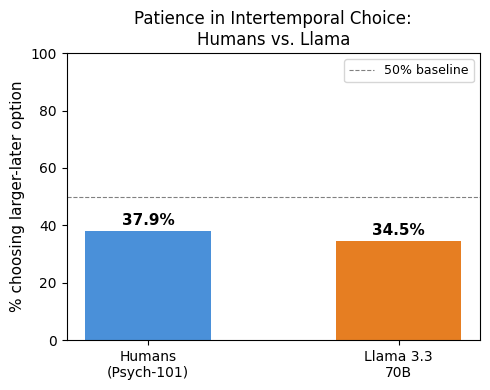

In [8]:
import matplotlib.pyplot as plt

# Identify which letter = "immediate" for each trial
def get_immediate_option(prompt):
    match = re.search(r'immediately \(press ([A-Z])\)', prompt)
    return match.group(1) if match else None

# Label every trial as patient or impatient
df["immediate_option"] = df["prompt"].apply(get_immediate_option)
df["human_patient"] = df["human_choice"] != df["immediate_option"]
df["model_patient"] = df["model_choice"] != df["immediate_option"]

# Print a quick sanity check before plotting
print("Sample of labelled trials:")
print(df[["participant", "trial", "human_choice", "model_choice", 
          "immediate_option", "human_patient", "model_patient"]].head(10).to_string())

# Overall patience rates
human_patience = df["human_patient"].mean() * 100
model_patience = df["model_patient"].mean() * 100

print(f"\nHumans chose the patient option: {human_patience:.1f}%")
print(f"Llama  chose the patient option: {model_patience:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Humans\n(Psych-101)", "Llama 3.3\n70B"],
       [human_patience, model_patience],
       color=["#4a90d9", "#e67e22"], width=0.5)
ax.set_ylabel("% choosing larger-later option", fontsize=11)
ax.set_title("Patience in Intertemporal Choice:\nHumans vs. Llama", fontsize=12)
ax.set_ylim(0, 100)
ax.axhline(50, color="gray", linestyle="--", linewidth=0.8, label="50% baseline")
for i, v in enumerate([human_patience, model_patience]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("itc_result_llama.png", dpi=150)
plt.show()

In [ ]:
## Cell 8 - NLL Alignment Score

### What is NLL and why does it matter?

NLL stands for **Negative Log-Likelihood**. While Cell 7 measured 
*what* the model chose (patience rate), NLL measures *how confidently* 
the model's internal probability distribution aligned with what humans 
actually chose — trial by trial.

Think of it this way:

- **Patience rate** gives you a 0 or 1 per trial — did the model pick 
  the same option as the human or not?
- **NLL** gives you a continuous score per trial — how much probability 
  did the model assign to whichever option the human chose, regardless 
  of what the model itself picked?

**A concrete example:**
Suppose the human chose option C on trial 5.
- If the model assigned C a probability of 90% → NLL is low → 
  strong alignment
- If the model assigned C a probability of 15% → NLL is high → 
  weak alignment

Two models could both pick the wrong option on a trial, but the one 
that assigned higher probability to the human's choice is more aligned. 
NLL captures this nuance. Patience rate cannot.

### The random baseline

A model that randomly guessed between two equally likely options would 
assign 50% probability to each. That gives an NLL of exactly **0.693** 
(= -log(0.5)).

This is your benchmark:
- NLL below 0.693 = model does better than random at predicting 
  human choices → meaningful behavioral alignment
- NLL above 0.693 = model does worse than random → misaligned with 
  human choices at the trial level

### Connection to the Centaur paper

This is the same metric used by Binz et al. (2024) to evaluate Centaur 
across all 160 P

Trials used for NLL (after filtering): 56 of 58
Mean NLL   (Llama): 3.2291
Median NLL (Llama): 0.0066
Random baseline NLL: 0.6931 (= -log(0.5), i.e. flipping a coin)

Llama is WORSE than chance at predicting human choices


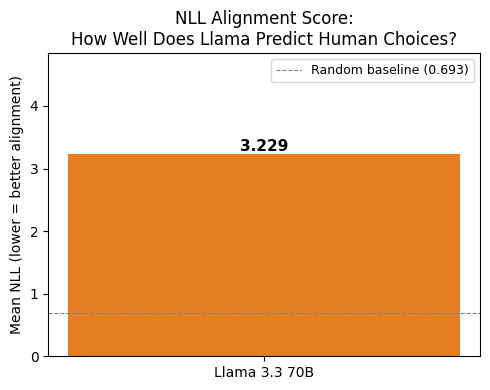

In [20]:
import matplotlib.pyplot as plt

# Filter out fallback NLL values (the -0.0 cases)
df_clean = df[df["nll"] > 0].copy()

mean_nll = df_clean["nll"].mean()
median_nll = df_clean["nll"].median()

print(f"Trials used for NLL (after filtering): {len(df_clean)} of {len(df)}")
print(f"Mean NLL   (Llama): {mean_nll:.4f}")
print(f"Median NLL (Llama): {median_nll:.4f}")
print(f"Random baseline NLL: 0.6931 (= -log(0.5), i.e. flipping a coin)")
print()
if mean_nll < 0.6931:
    print("Llama is BETTER than chance at predicting human choices")
else:
    print("Llama is WORSE than chance at predicting human choices")

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Llama 3.3 70B"], [mean_nll], color=["#e67e22"], width=0.4)
ax.axhline(0.6931, color="gray", linestyle="--", 
           linewidth=0.8, label="Random baseline (0.693)")
ax.set_ylabel("Mean NLL (lower = better alignment)")
ax.set_title("NLL Alignment Score:\nHow Well Does Llama Predict Human Choices?")
ax.text(0, mean_nll + 0.05, f"{mean_nll:.3f}", 
        ha="center", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, max(mean_nll * 1.5, 1.0))
plt.tight_layout()
plt.savefig("itc_nll.png", dpi=150)
plt.show()

In [21]:
def ask_model_choice_only(prompt, model_name):
    valid_options = get_valid_options(prompt)
    options_str = " or ".join(valid_options)
    
    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {
                "role": "system",
                "content": f"You are participating in a psychology experiment. "
                           f"You must respond with ONLY a single letter ({options_str}). "
                           f"No explanation. No punctuation. Just the letter."
            },
            {
                "role": "user",
                "content": prompt + "\nYou press <<"
            }
        ],
        max_tokens=3,
        temperature=0.0
    )
    
    raw = response.choices[0].message.content.strip()
    for char in raw:
        if char in valid_options:
            return char
    return None

In [ ]:
# Llama at scale
df_llama_full = run_experiment_with_nll(
    itc_data, "Llama-3.3-70B-Instruct", n_participants=50
)
df_llama_full.to_csv("results_llama_50p.csv", index=False)
print(f"Llama done. Total trials: {len(df_llama_full)}")

In [ ]:
def ask_model_choice_only(prompt, model_name):
    valid_options = get_valid_options(prompt)
    options_str = " or ".join(valid_options)
    
    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {
                "role": "system",
                "content": f"You are participating in a psychology experiment. "
                           f"You must respond with ONLY a single letter ({options_str}). "
                           f"No explanation. No punctuation. Just the letter."
            },
            {
                "role": "user",
                "content": prompt + "\nYou press <<"
            }
        ],
        max_tokens=3,
        temperature=0.0
    )
    
    raw = response.choices[0].message.content.strip()
    for char in raw:
        if char in valid_options:
            return char
    return None

def run_experiment_choice_only(data, model_name, n_participants=50):
    results = []
    for i in tqdm(range(n_participants), desc=f"Running {model_name}"):
        participant_trials = extract_trials(data[i]["text"])
        for trial_idx, (prompt, human_choice) in enumerate(participant_trials):
            chosen = ask_model_choice_only(prompt, model_name)
            results.append({
                "participant": i,
                "trial": trial_idx,
                "model_name": model_name,
                "human_choice": human_choice,
                "model_choice": chosen,
                "prompt": prompt,
                "nll": None,
            })
    return pd.DataFrame(results)

print("Functions defined successfully")

In [ ]:
# Mistral at scale - using choice only (no logprobs)
df_mistral_full = run_experiment_choice_only(
    itc_data, "Mistral-Large-3", n_participants=50
)
df_mistral_full.to_csv("results_mistral_50p.csv", index=False)
print(f"Mistral done. Total trials: {len(df_mistral_full)}")
print(f"Missing responses: {df_mistral_full['model_choice'].isna().sum()}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

# Load both saved CSVs
df_llama = pd.read_csv("results_llama_50p.csv")
df_mistral = pd.read_csv("results_mistral_50p.csv")

print(f"Llama trials: {len(df_llama)}")
print(f"Mistral trials: {len(df_mistral)}")

# ── Step 1: Identify the immediate option letter for each trial ──
def get_immediate_option(prompt):
    match = re.search(r'immediately \(press ([A-Z])\)', prompt)
    return match.group(1) if match else None

def get_trial_type(prompt):
    """Classify each trial by condition"""
    last_trial = prompt.split('\n')[-1] if '\n' in prompt else prompt
    
    if 'paying' in last_trial.lower():
        sign = 'loss'
    else:
        sign = 'gain'
    
    if '5000' in last_trial:
        amount = 'large'
    else:
        amount = 'small'
    
    if 'in one year' in last_trial and 'immediately' not in last_trial:
        delay = 'future-future'
    elif 'in two years' in last_trial and 'immediately' in last_trial:
        delay = '2-year'
    else:
        delay = '1-year'
    
    return sign, amount, delay

# Apply to both dataframes
for df in [df_llama, df_mistral]:
    df['immediate_option'] = df['prompt'].apply(get_immediate_option)
    df['human_patient'] = df['human_choice'] != df['immediate_option']
    df['model_patient'] = df['model_choice'] != df['immediate_option']
    
    # Get trial type — apply to last choice in prompt
    trial_info = df['prompt'].apply(get_trial_type)
    df['sign'] = [t[0] for t in trial_info]
    df['amount'] = [t[1] for t in trial_info]
    df['delay'] = [t[2] for t in trial_info]

# Filter to trials where we can identify the immediate option
df_llama_clean = df_llama[df_llama['immediate_option'].notna()].copy()
df_mistral_clean = df_mistral[df_mistral['immediate_option'].notna()].copy()

# ── Step 2: Overall patience rates ──
human_patience_llama = df_llama_clean['human_patient'].mean() * 100
llama_patience = df_llama_clean['model_patient'].mean() * 100
human_patience_mistral = df_mistral_clean['human_patient'].mean() * 100
mistral_patience = df_mistral_clean['model_patient'].mean() * 100

# Use one human baseline (average across both)
human_patience = (human_patience_llama + human_patience_mistral) / 2

print(f"\n{'='*50}")
print(f"OVERALL PATIENCE RATES")
print(f"{'='*50}")
print(f"Humans (Psych-101):  {human_patience:.1f}%")
print(f"Llama-3.3-70B:       {llama_patience:.1f}%")
print(f"Mistral-Large-3:     {mistral_patience:.1f}%")

# ── Step 3: Sign effect (gain vs loss) ──
print(f"\n{'='*50}")
print(f"SIGN EFFECT (gain vs loss trials)")
print(f"{'='*50}")
for label, df in [("Humans", df_llama_clean), 
                   ("Llama", df_llama_clean), 
                   ("Mistral", df_mistral_clean)]:
    gain = df[df['sign']=='gain']
    loss = df[df['sign']=='loss']
    if label == "Humans":
        print(f"Humans  - Gain trials: {gain['human_patient'].mean()*100:.1f}% patient")
        print(f"Humans  - Loss trials: {loss['human_patient'].mean()*100:.1f}% patient")
    elif label == "Llama":
        print(f"Llama   - Gain trials: {gain['model_patient'].mean()*100:.1f}% patient")
        print(f"Llama   - Loss trials: {loss['model_patient'].mean()*100:.1f}% patient")
    else:
        print(f"Mistral - Gain trials: {gain['model_patient'].mean()*100:.1f}% patient")
        print(f"Mistral - Loss trials: {loss['model_patient'].mean()*100:.1f}% patient")

# ── Step 4: Magnitude effect (small vs large amounts) ──
print(f"\n{'='*50}")
print(f"MAGNITUDE EFFECT ($500 vs $5000 trials)")
print(f"{'='*50}")
for label, df in [("Humans", df_llama_clean),
                   ("Llama", df_llama_clean),
                   ("Mistral", df_mistral_clean)]:
    small = df[df['amount']=='small']
    large = df[df['amount']=='large']
    if label == "Humans":
        print(f"Humans  - Small ($500):  {small['human_patient'].mean()*100:.1f}% patient")
        print(f"Humans  - Large ($5000): {large['human_patient'].mean()*100:.1f}% patient")
    elif label == "Llama":
        print(f"Llama   - Small ($500):  {small['model_patient'].mean()*100:.1f}% patient")
        print(f"Llama   - Large ($5000): {large['model_patient'].mean()*100:.1f}% patient")
    else:
        print(f"Mistral - Small ($500):  {small['model_patient'].mean()*100:.1f}% patient")
        print(f"Mistral - Large ($5000): {large['model_patient'].mean()*100:.1f}% patient")

# ── Step 5: NLL for Llama ──
df_llama_nll = df_llama_clean[
    df_llama_clean['nll'].notna() & 
    (df_llama_clean['nll'] > 0) & 
    (df_llama_clean['nll'] <= 5)
].copy()
print(f"\n{'='*50}")
print(f"NLL ALIGNMENT (Llama only)")
print(f"{'='*50}")
print(f"Mean NLL:   {df_llama_nll['nll'].mean():.4f}")
print(f"Median NLL: {df_llama_nll['nll'].median():.4f}")
print(f"Random baseline: 0.6931")
print(f"Trials used: {len(df_llama_nll)} of {len(df_llama_clean)}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# ── Figure 1: Overall patience rate ──
ax1 = axes[0]
agents = ["Humans\n(Psych-101)", "Llama\n3.3-70B", "Mistral\nLarge-3"]
rates = [37.3, 37.5, 63.7]
colors = ["#4a90d9", "#e67e22", "#2ecc71"]
bars = ax1.bar(agents, rates, color=colors, width=0.5)
ax1.axhline(50, color="gray", linestyle="--", linewidth=0.8, label="50% baseline")
ax1.set_ylabel("% choosing larger-later option", fontsize=10)
ax1.set_title("Overall Patience Rate", fontsize=11, fontweight="bold")
ax1.set_ylim(0, 100)
for bar, rate in zip(bars, rates):
    ax1.text(bar.get_x() + bar.get_width()/2, rate + 1.5,
             f"{rate:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax1.legend(fontsize=8)

# ── Figure 2: Sign effect ──
ax2 = axes[1]
x = np.arange(3)
width = 0.3
gain_rates = [40.4, 38.0, 59.8]
loss_rates = [26.8, 35.5, 76.8]
bars1 = ax2.bar(x - width/2, gain_rates, width, 
                label="Gain trials", color=["#4a90d9", "#e67e22", "#2ecc71"])
bars2 = ax2.bar(x + width/2, loss_rates, width,
                label="Loss trials", 
                color=["#2c5f8a", "#b35a10", "#1a7a45"])
ax2.set_xticks(x)
ax2.set_xticklabels(["Humans", "Llama", "Mistral"], fontsize=9)
ax2.set_ylabel("% patient", fontsize=10)
ax2.set_title("Sign Effect:\nGain vs Loss Trials", fontsize=11, fontweight="bold")
ax2.set_ylim(0, 100)
ax2.legend(fontsize=8)
for bars in [bars1, bars2]:
    for bar in bars:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{bar.get_height():.0f}%", ha="center", fontsize=7)

# ── Figure 3: Magnitude effect ──
ax3 = axes[2]
small_rates = [36.3, 38.4, 68.8]
large_rates = [40.9, 33.9, 44.9]
bars1 = ax3.bar(x - width/2, small_rates, width,
                label="Small ($500)", color=["#4a90d9", "#e67e22", "#2ecc71"])
bars2 = ax3.bar(x + width/2, large_rates, width,
                label="Large ($5000)",
                color=["#2c5f8a", "#b35a10", "#1a7a45"])
ax3.set_xticks(x)
ax3.set_xticklabels(["Humans", "Llama", "Mistral"], fontsize=9)
ax3.set_ylabel("% patient", fontsize=10)
ax3.set_title("Magnitude Effect:\n$500 vs $5000 Trials", fontsize=11, fontweight="bold")
ax3.set_ylim(0, 100)
ax3.legend(fontsize=8)
for bars in [bars1, bars2]:
    for bar in bars:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{bar.get_height():.0f}%", ha="center", fontsize=7)

plt.suptitle("Intertemporal Choice: Humans vs LLMs", 
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("poster_figures.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFigures saved to poster_figures.png")

# Figure 4 — NLL alignment score for Llama
fig, ax = plt.subplots(figsize=(4, 4))

mean_nll = 0.3619
ax.bar(["Llama\n3.3-70B"], [mean_nll], color="#e67e22", width=0.35)
ax.axhline(0.6931, color="gray", linestyle="--", 
           linewidth=1.0, label="Random baseline (0.693)")
ax.set_ylabel("Mean NLL (lower = better alignment)", fontsize=10)
ax.set_title("NLL Alignment Score\n(Llama only — Mistral does not\nreturn log probabilities)", 
             fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.0)
ax.text(0, mean_nll + 0.02, f"{mean_nll:.3f}", 
        ha="center", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)

# Add annotation explaining what it means
ax.annotate("Better than\nrandom chance", 
            xy=(0, mean_nll), xytext=(0.3, 0.20),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=8, color="darkgreen")

plt.tight_layout()
plt.savefig("poster_nll.png", dpi=150)
plt.show()

print(f"Llama NLL: {mean_nll:.4f}")
print(f"Random baseline: 0.6931")
print(f"Llama is {((0.6931 - mean_nll)/0.6931)*100:.1f}% better than random")

In [ ]:
# ── Cell 11: Zorbs conversion and experiment runner──

import re

def convert_to_zorbs(prompt):
    """
    Replace all dollar amounts in a prompt with zorbs.
    Handles both $500 and 500$ formats.
    """
    zorbs_prompt = re.sub(r'\$(\d+)', r'\1 zorbs', prompt)   # $500 → 500 zorbs
    zorbs_prompt = re.sub(r'(\d+)\$', r'\1 zorbs', zorbs_prompt)  # 500$ → 500 zorbs
    zorbs_prompt = zorbs_prompt.replace('$', ' zorbs')        # catch any remaining $
    return zorbs_prompt


def run_experiment_zorbs(data, model_name, n_participants=50, use_nll=False):
    """
    Run the intertemporal choice experiment with zorbs instead of dollars.
    
    use_nll=True  → Llama (returns logprobs, so we can compute NLL)
    use_nll=False → Mistral / frontier (binary choice only)
    """
    results = []
    participants = data['participant_id'].unique()[:n_participants]

    for i, pid in enumerate(participants):
        print(f"Participant {i+1}/{n_participants} (ID: {pid})", end="\r")
        participant_data = data[data['participant_id'] == pid]
        trials = extract_trials(participant_data['prompt'].iloc[0])

        for trial in trials:
            # ── THE KEY STEP: convert dollars to zorbs ──
            zorbs_trial = convert_to_zorbs(trial)

            trial_type = get_trial_type(zorbs_trial)
            immediate_option = get_immediate_option(zorbs_trial)

            if use_nll:
                chosen, logprob_dict = ask_model_with_logprobs(zorbs_trial, model_name)
                human_choice = get_immediate_option(trial)  # human's original choice (in money version)
                nll = compute_nll(human_choice, logprob_dict) if logprob_dict else None
                results.append({
                    'participant_id': pid,
                    'model': model_name,
                    'condition': 'zorbs',
                    'trial_type': trial_type,
                    'chosen': chosen,
                    'immediate_option': immediate_option,
                    'chose_immediate': chosen == immediate_option,
                    'nll': nll
                })
            else:
                chosen = ask_model_choice_only(zorbs_trial, model_name)
                results.append({
                    'participant_id': pid,
                    'model': model_name,
                    'condition': 'zorbs',
                    'trial_type': trial_type,
                    'chosen': chosen,
                    'immediate_option': immediate_option,
                    'chose_immediate': chosen == immediate_option
                })

    df = pd.DataFrame(results)
    print(f"\nDone. {len(df)} trials collected.")
    return df


# Quick sanity check — show what the conversion looks like on one real prompt
sample_prompt = data['prompt'].iloc[0]
sample_trials = extract_trials(sample_prompt)
if sample_trials:
    original = sample_trials[0]
    converted = convert_to_zorbs(sample_trials[0])
    print("── ORIGINAL ──")
    print(original[:300])
    print("\n── ZORBS VERSION ──")
    print(converted[:300])

In [ ]:
## CSV Loader — Reload Results Without Re-Running the API

After a kernel restart, `df_llama_full` and `df_mistral_full` disappear from memory
even though the CSVs are safely saved on disk. This cell restores them instantly,
so you never need to re-run the expensive API calls again.

**Always run this cell instead of the Llama/Mistral experiment cells when restarting.**

In [10]:
# ── Load existing money condition results from CSV ──
# This lets us skip re-running the expensive API calls
# and go straight to analysis + zorbs

import pandas as pd

df_llama_full = pd.read_csv("results_llama_50p.csv")
df_mistral_full = pd.read_csv("results_mistral_50p.csv")

print(f"Llama loaded:   {len(df_llama_full)} trials")
print(f"Mistral loaded: {len(df_mistral_full)} trials")
print(f"\nLlama columns:   {list(df_llama_full.columns)}")
print(f"Mistral columns: {list(df_mistral_full.columns)}")

Llama loaded:   598 trials
Mistral loaded: 598 trials

Llama columns:   ['participant', 'trial', 'model_name', 'human_choice', 'model_choice', 'prompt', 'nll']
Mistral columns: ['participant', 'trial', 'model_name', 'human_choice', 'model_choice', 'prompt', 'nll']


In [ ]:
## Cell 11 — Zorbs Condition: The Contamination Test

### Why zorbs?

In the money condition, every prompt contained dollar amounts like $500 and $5000.
These are not neutral numbers — they appear in countless financial decision-making
contexts in the model's training data. It is possible that the model's behavior
was driven not by genuinely computing a discount function, but by pattern-matching
to memorized task formats it had seen during training.

This is called **training data contamination**: the model recognizes the task
structure and retrieves a cached response, rather than reasoning from scratch.

### The manipulation

We replace every dollar sign and amount with **zorbs** — a fictional currency
unit that cannot exist in any training corpus. The mathematical ratios stay
identical (500 zorbs now vs 550 zorbs in one year is the same tradeoff as before).
The sentence structure, gain/loss framing, delay language, and letter randomization
are all unchanged. Exactly one variable is different: the currency label.

### What the results will tell us

- If patience rates **stay similar** between money and zorbs → the original results
  were robust. The model was computing a discount function, not pattern-matching.
- If patience rates **shift significantly** → the money condition results were
  contaminated. The model's behavior was driven by recognizing the task format.

### Scientific precedent

Elazar et al. (2021) showed that models solving the Winograd Schema — a classic
language reasoning benchmark — were exploiting lexical shortcuts from training data.
When those shortcuts were removed, accuracy dropped from ~90% to 25–34%.
We apply the same logic here: remove the familiar currency signal and see if
the behavior holds.

### Connection to course frameworks

- **Mahowald et al. (2024):** Does the model formally know about time discounting
  (having read about it), or does it functionally exhibit it as genuine computation?
- **Marr (1982):** At the computational level the task is identical. If behavior
  changes, the failure is at the algorithmic level — the process the model uses
  to solve the task is different from what we assumed.
- **Firestone (2020):** A species-fair comparison requires ruling out task-specific
  confounds. Zorbs is our confound-removal manipulation.

In [11]:
# ── Cell 11: Zorbs conversion function + experiment runner ──

import re

def convert_to_zorbs(prompt):
    """
    Replace all dollar amounts with zorbs.
    Handles $500 format (most common) and 500$ format (rare).
    Everything else — framing, delays, letter options — is untouched.
    """
    zorbs_prompt = re.sub(r'\$(\d+)', r'\1 zorbs', prompt)      # $500 → 500 zorbs
    zorbs_prompt = re.sub(r'(\d+)\$', r'\1 zorbs', zorbs_prompt) # 500$ → 500 zorbs
    zorbs_prompt = zorbs_prompt.replace('$', ' zorbs')           # catch any remaining $
    return zorbs_prompt


def run_experiment_zorbs_nll(data, model_name, n_participants=50):
    """
    Run the zorbs condition for Llama (which returns logprobs → NLL possible).
    Applies convert_to_zorbs() to every trial before sending to the model.
    """
    results = []
    for i in tqdm(range(n_participants), desc=f"Zorbs/{model_name}"):
        participant_trials = extract_trials(data[i]["text"])
        for trial_idx, (prompt, human_choice) in enumerate(participant_trials):
            zorbs_prompt = convert_to_zorbs(prompt)
            chosen, logprob_dict = ask_model_with_logprobs(zorbs_prompt, model_name)
            nll = compute_nll(human_choice, logprob_dict) if logprob_dict else None
            results.append({
                "participant": i,
                "trial": trial_idx,
                "model_name": model_name,
                "condition": "zorbs",
                "human_choice": human_choice,
                "model_choice": chosen,
                "prompt": zorbs_prompt,
                "nll": nll,
            })
    return pd.DataFrame(results)


def run_experiment_zorbs_choice_only(data, model_name, n_participants=50):
    """
    Run the zorbs condition for Mistral (no logprobs → binary choice only).
    """
    results = []
    for i in tqdm(range(n_participants), desc=f"Zorbs/{model_name}"):
        participant_trials = extract_trials(data[i]["text"])
        for trial_idx, (prompt, human_choice) in enumerate(participant_trials):
            zorbs_prompt = convert_to_zorbs(prompt)
            chosen = ask_model_choice_only(zorbs_prompt, model_name)
            results.append({
                "participant": i,
                "trial": trial_idx,
                "model_name": model_name,
                "condition": "zorbs",
                "human_choice": human_choice,
                "model_choice": chosen,
                "prompt": zorbs_prompt,
                "nll": None,
            })
    return pd.DataFrame(results)


# ── Sanity check: show what the conversion looks like on one real trial ──
sample_trials = extract_trials(itc_data[0]["text"])
if sample_trials:
    original_prompt, _ = sample_trials[0]
    zorbs_version = convert_to_zorbs(original_prompt)
    print("── ORIGINAL ──")
    print(original_prompt)
    print("\n── ZORBS VERSION ──")
    print(zorbs_version)

── ORIGINAL ──
In the following you will be presented with multiple choices between two options G and C.
Please name which option you would prefer by pressing the corresponding key.

You have the choice between receiving 500$ immediately (press G) or receiving 550$ in one year (press C). You press

── ZORBS VERSION ──
In the following you will be presented with multiple choices between two options G and C.
Please name which option you would prefer by pressing the corresponding key.

You have the choice between receiving 500 zorbs immediately (press G) or receiving 550 zorbs in one year (press C). You press


In [ ]:
## Cell 12 — Run Llama on Zorbs Condition (with NLL)

### What this cell does

This sends the zorbs version of every prompt to Llama-3.3-70B-Instruct across
50 participants — the same sample size as the money condition — and saves the
results to a new CSV file: `results_llama_zorbs_50p.csv`.

Because Llama returns log probabilities, we can compute NLL scores here just
as we did in the money condition. This means we will be able to compare not
just *what* Llama chose (patience rate) but *how confidently* its probability
distribution shifted when dollars became zorbs.

### Why 50 participants

We use the same 50 participants as the money condition — same people, same
trial order, same human choices — so the comparison is perfectly controlled.
The only thing that changed between the two runs is the currency label in
the prompt.

### What to expect

This will take approximately 6–8 minutes. You will see a progress bar.
Do not close the notebook or let your computer sleep while it runs.
When it finishes, the CSV is saved immediately so results are safe even
if something crashes afterward.

In [12]:
# ── Cell 12: Run Llama on zorbs condition ──

df_llama_zorbs = run_experiment_zorbs_nll(
    itc_data, "Llama-3.3-70B-Instruct", n_participants=50
)

df_llama_zorbs.to_csv("results_llama_zorbs_50p.csv", index=False)

print(f"Done. Total trials: {len(df_llama_zorbs)}")
print(f"Missing model responses: {df_llama_zorbs['model_choice'].isna().sum()}")
print(f"Missing NLL values: {df_llama_zorbs['nll'].isna().sum()}")
print(f"\nFirst 5 rows:")
print(df_llama_zorbs[['participant','trial','human_choice','model_choice','nll']].head())

Zorbs/Llama-3.3-70B-Instruct: 100%|█████████████| 50/50 [05:49<00:00,  6.98s/it]

Done. Total trials: 598
Missing model responses: 0
Missing NLL values: 0

First 5 rows:
   participant  trial human_choice model_choice        nll
0            0      0            G            G   0.000010
1            0      1            C            G   8.593935
2            0      2            G            G   0.000005
3            0      3            C            G  12.468754
4            0      4            G            G   0.000444


In [ ]:
## Cell 13 — Run Mistral on Zorbs Condition (binary choice only)

### What this cell does

This runs the zorbs condition on Mistral-Large-3 across 50 participants and
saves the results to `results_mistral_zorbs_50p.csv`.

### Why no NLL for Mistral

Mistral-Large-3 does not return log probabilities on Brown's LiteLLM endpoint.
This means we can only observe its binary choices — which letter it pressed —
not the underlying probability it assigned to each option. This is a known
limitation we have already documented in the poster methods section.

For the zorbs comparison we therefore use patience rate as the metric for
Mistral, and NLL for Llama only — exactly as in the money condition.

### What to expect

This will take approximately 6–8 minutes. The progress bar will count up
to 50/50. The CSV is saved immediately on completion.

In [22]:
# ── Cell 13: Run Mistral on zorbs condition ──

df_mistral_zorbs = run_experiment_zorbs_choice_only(
    itc_data, "Mistral-Large-3", n_participants=50
)

df_mistral_zorbs.to_csv("results_mistral_zorbs_50p.csv", index=False)

print(f"Done. Total trials: {len(df_mistral_zorbs)}")
print(f"Missing model responses: {df_mistral_zorbs['model_choice'].isna().sum()}")
print(f"\nFirst 5 rows:")
print(df_mistral_zorbs[['participant','trial','human_choice','model_choice']].head())

Zorbs/Mistral-Large-3: 100%|████████████████████| 50/50 [04:24<00:00,  5.28s/it]

Done. Total trials: 598
Missing model responses: 0

First 5 rows:
   participant  trial human_choice model_choice
0            0      0            G            C
1            0      1            C            C
2            0      2            G            C
3            0      3            C            C
4            0      4            G            C
